# Model Evaluation and Finalization

In this notebook, we evaluate the trained regression models and finalize the best model.

Main tasks:

- Compare model performance visually
- Analyze predictions of the best model
- Perform residual analysis
- Save the final model for future use

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
sys.path.append(os.path.abspath(".."))

## Load Cleaned Dataset

In [4]:
df = pd.read_csv("../data/processed/cleaned_train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000


## Separate Features and Target

In [5]:
X = df.drop("SalePrice", axis=1)
y = np.log1p(df["SalePrice"])

## Identify Numerical and Categorical Features

In [6]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Build Preprocessing Pipelines

In [8]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Define Models

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

## Train and Evaluate Models

In [10]:
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Pipeline": pipeline,
        "Predictions": y_pred
    })

## Create Results Table

In [11]:
results_df = pd.DataFrame([
    {
        "Model": r["Model"],
        "MAE": r["MAE"],
        "RMSE": r["RMSE"],
        "R2": r["R2"]
    }
    for r in results
])

results_df = results_df.sort_values(by="RMSE").reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,Ridge,0.091197,0.127026,0.913533
1,Linear Regression,0.089380,0.128658,0.911298
2,Gradient Boosting,0.093907,0.137109,0.899262
3,Random Forest,0.099223,0.145149,0.887101
4,Lasso,0.337134,0.433244,-0.005837


## Plot Model Comparison

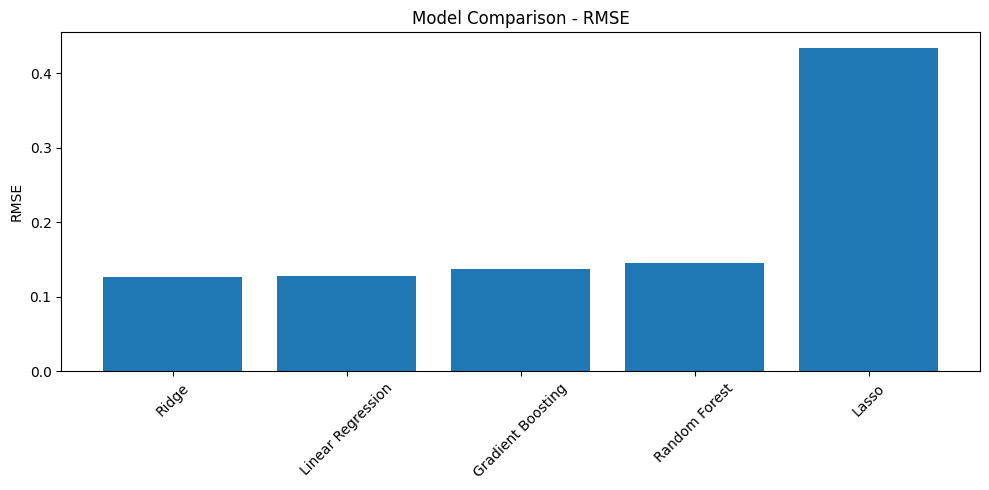

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")

plt.tight_layout()

plt.savefig("../assets/model_comparison.png")

plt.show()

## Select Best Model

In [ ]:
best_result = min(results, key=lambda x: x["RMSE"])
best_model = best_result["Pipeline"]
best_predictions = best_result["Predictions"]

print("Best Model:", best_result["Model"])
print("Best MAE:", best_result["MAE"])
print("Best RMSE:", best_result["RMSE"])
print("Best R2:", best_result["R2"])

Best Model: Ridge
Best MAE: 0.09119741221870986
Best RMSE: 0.12702637691585072
Best R2: 0.9135329566904389


## Actual vs Predicted Values

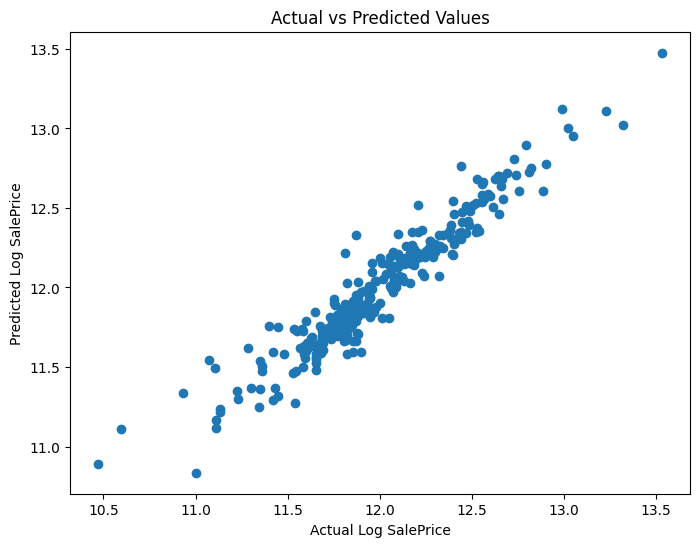

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_predictions)
plt.xlabel("Actual Log SalePrice")
plt.ylabel("Predicted Log SalePrice")
plt.title("Actual vs Predicted Values")
plt.show()

## Residual Analysis

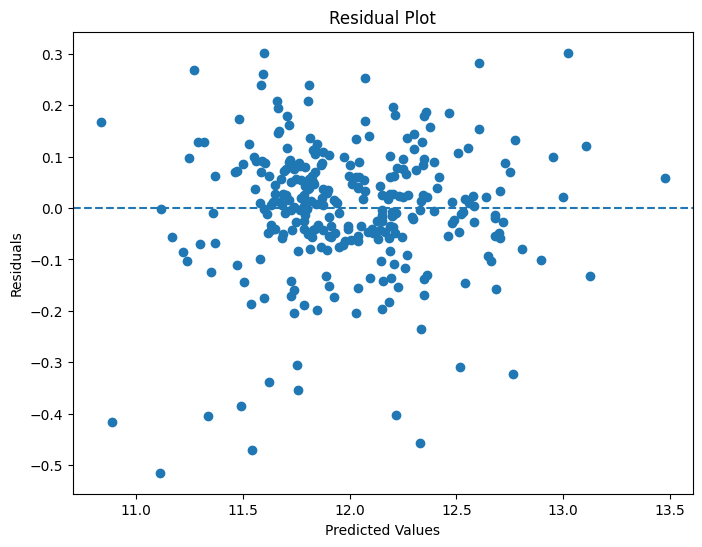

In [ ]:
residuals = y_test - best_predictions

plt.figure(figsize=(8, 6))
plt.scatter(best_predictions, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## Save the Best Model

In [ ]:
joblib.dump(best_model, "../models/best_house_price_model.pkl")

['../models/best_house_price_model.pkl']

## Final Summary

In this project:

- We explored the dataset
- Cleaned missing values
- Performed feature engineering
- Trained multiple regression models
- Compared their performance
- Selected and saved the best-performing model

The final model is now ready for deployment or future predictions.